In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3

from pathlib import Path
import sys

def find_project_root(start: Path, marker: str = "src") -> Path:
    current = start.resolve()
    for path in [current, *current.parents]:
        if (path / marker).exists():
            return path
    raise RuntimeError(f"Could not find project root containing '{marker}'")

PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/rawls/quant-lab


In [2]:
base = PROJECT_ROOT / "experiments/completed/exp_004_project04_final/strategy_timeseries"

import pandas as pd

df_ls30 = pd.read_csv(base / "ls_30pct.csv")
df_blend = pd.read_csv(base / "blend_60_40_ls20_plus_ls30.csv")

returns_ls30 = df_ls30["portfolio_return"]
returns_blend = df_blend["portfolio_return"]

equity_ls30 = df_ls30["equity_curve"]
equity_blend = df_blend["equity_curve"]

In [3]:
# Blend 60/40
from src.risk.drawdown import compute_drawdown, drawdown_exposure, apply_exposure_to_return

dd_blend = compute_drawdown((1 + returns_blend).cumprod())
exp_blend = drawdown_exposure(dd_blend)
ret_blend_dd = apply_exposure_to_return(returns_blend, exp_blend)

# LS 30%
dd_ls30 = compute_drawdown((1 + returns_ls30).cumprod())
exp_ls30 = drawdown_exposure(dd_ls30)
ret_ls30_dd = apply_exposure_to_return(returns_ls30, exp_ls30)

In [4]:
equity_blend_dd = (1 + ret_blend_dd).cumprod()
equity_ls30_dd = (1 + ret_ls30_dd).cumprod()

In [5]:
from src.utils.metrics import sharpe_ratio, max_drawdown

def compute_cagr(equity_curve):
    total_return = equity_curve.iloc[-1] / equity_curve.iloc[0]
    n_years = len(equity_curve) / 252
    return total_return ** (1 / n_years) - 1

def annual_vol(returns):
    return returns.std() * np.sqrt(252)

def calmar_ratio(equity_curve):
    cagr = compute_cagr(equity_curve)
    mdd = abs(max_drawdown(equity_curve))
    return cagr / mdd if mdd != 0 else np.nan

In [6]:
import numpy as np

comparison = pd.DataFrame([
    {
        "Strategy": "Blend 60/40 Baseline",
        "Sharpe": sharpe_ratio(returns_blend),
        "MDD": max_drawdown(equity_blend),
        "CAGR": compute_cagr(equity_blend),
        "Vol": annual_vol(returns_blend),
        "Calmar": calmar_ratio(equity_blend),
    },
    {
        "Strategy": "Blend 60/40 + DD Control",
        "Sharpe": sharpe_ratio(ret_blend_dd),
        "MDD": max_drawdown(equity_blend_dd),
        "CAGR": compute_cagr(equity_blend_dd),
        "Vol": annual_vol(ret_blend_dd),
        "Calmar": calmar_ratio(equity_blend_dd),
    },
    {
        "Strategy": "LS 30% Baseline",
        "Sharpe": sharpe_ratio(returns_ls30),
        "MDD": max_drawdown(df_ls30["equity_curve"]),
        "CAGR": compute_cagr(df_ls30["equity_curve"]),
        "Vol": annual_vol(returns_ls30),
        "Calmar": calmar_ratio(df_ls30["equity_curve"]),
    },
    {
        "Strategy": "LS 30% + DD Control",
        "Sharpe": sharpe_ratio(ret_ls30_dd),
        "MDD": max_drawdown(equity_ls30_dd),
        "CAGR": compute_cagr(equity_ls30_dd),
        "Vol": annual_vol(ret_ls30_dd),
        "Calmar": calmar_ratio(equity_ls30_dd),
    },
]).round(3)

comparison

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,Blend 60/40 Baseline,1.510,-0.614,0.378,0.230,0.616
1,Blend 60/40 + DD Control,1.393,-0.328,0.175,0.121,0.533
2,LS 30% Baseline,1.418,-0.549,0.307,0.204,0.559
3,LS 30% + DD Control,1.004,-0.322,0.115,0.116,0.356


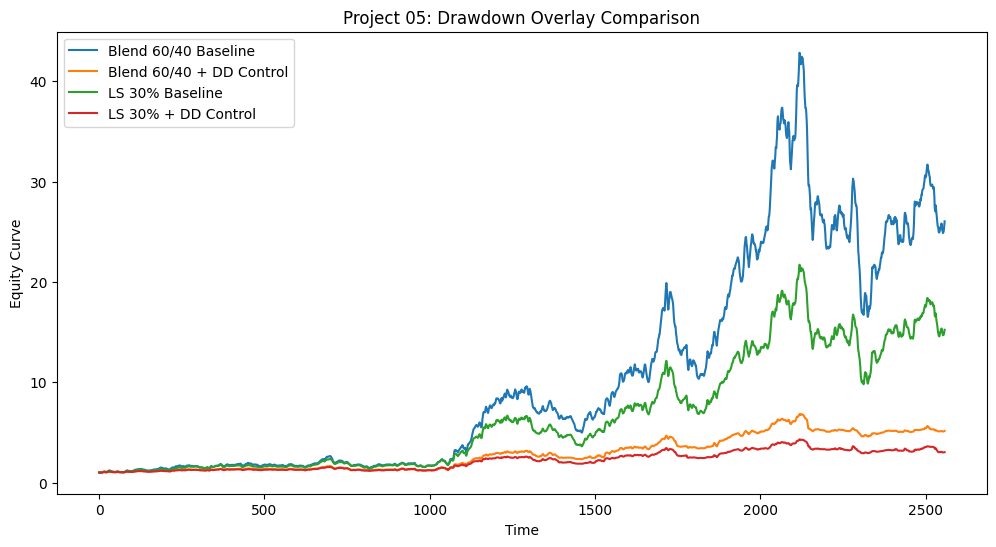

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_blend["equity_curve"], label="Blend 60/40 Baseline")
plt.plot(equity_blend_dd, label="Blend 60/40 + DD Control")
plt.plot(df_ls30["equity_curve"], label="LS 30% Baseline")
plt.plot(equity_ls30_dd, label="LS 30% + DD Control")
plt.legend()
plt.title("Project 05: Drawdown Overlay Comparison")
plt.xlabel("Time")
plt.ylabel("Equity Curve")
plt.show()

**Testing - Other Strategies**

In [8]:
strategy_base = PROJECT_ROOT / "experiments/completed/exp_004_project04_final/strategy_timeseries"

strategy_files = sorted(strategy_base.glob("*.csv"))

all_strategies = {}

for file in strategy_files:
    df = pd.read_csv(file)
    all_strategies[file.stem] = df

print("Loaded strategies:")
for k in all_strategies.keys():
    print("-", k)

Loaded strategies:
- blend_40_60_ls20_plus_ls30
- blend_50_50_ls20_plus_ls30
- blend_60_40_ls20_plus_ls30
- blend_70_30_ls20_plus_ls30
- ls_20pct
- ls_20pct_plus_linear
- ls_20pct_plus_pow_0.7
- ls_20pct_plus_sqrt
- ls_20pct_plus_sqrt_partial
- ls_20pct_plus_sqrt_partial_normalized
- ls_30pct
- ls_30pct_plus_sqrt_partial_norm


In [9]:
all_results = []

for name, df in all_strategies.items():
    returns = df["portfolio_return"].fillna(0)
    equity = (1 + returns).cumprod()

    dd = compute_drawdown(equity)
    exp = drawdown_exposure(dd)
    ret_dd = apply_exposure_to_return(returns, exp)
    equity_dd = (1 + ret_dd).cumprod()

    all_results.append({
        "Strategy": name,
        "Sharpe_base": sharpe_ratio(returns),
        "MDD_base": max_drawdown(equity),
        "CAGR_base": compute_cagr(equity),
        "Vol_base": annual_vol(returns),
        "Calmar_base": calmar_ratio(equity),

        "Sharpe_dd": sharpe_ratio(ret_dd),
        "MDD_dd": max_drawdown(equity_dd),
        "CAGR_dd": compute_cagr(equity_dd),
        "Vol_dd": annual_vol(ret_dd),
        "Calmar_dd": calmar_ratio(equity_dd),

        "Avg_Exposure": exp.shift(1).fillna(1.0).mean(),
    })

In [10]:
all_results_df = pd.DataFrame(all_results).round(3)

all_results_df["Delta_Sharpe"] = (all_results_df["Sharpe_dd"] - all_results_df["Sharpe_base"]).round(3)
all_results_df["Delta_MDD"] = (all_results_df["MDD_dd"] - all_results_df["MDD_base"]).round(3)
all_results_df["Delta_CAGR"] = (all_results_df["CAGR_dd"] - all_results_df["CAGR_base"]).round(3)
all_results_df["Delta_Calmar"] = (all_results_df["Calmar_dd"] - all_results_df["Calmar_base"]).round(3)

all_results_df

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086


In [11]:
all_results_df.sort_values(by="Sharpe_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064


In [12]:
all_results_df.sort_values(by="Calmar_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038


In [13]:
all_results_df.sort_values(by="Delta_MDD", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127


In [14]:
focus_df = all_results_df[
    all_results_df["Strategy"].str.contains("ls_20|blend", case=False, regex=True)
].copy()

focus_df.sort_values(by="Sharpe_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064


**Only LS20 Family & Blends**

In [15]:
focus_df.sort_values(by="Calmar_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Vol_base,Calmar_base,Sharpe_dd,MDD_dd,CAGR_dd,Vol_dd,Calmar_dd,Avg_Exposure,Delta_Sharpe,Delta_MDD,Delta_CAGR,Delta_Calmar
4,ls_20pct,1.516,-0.655,0.425,0.255,0.648,1.405,-0.346,0.195,0.133,0.564,0.454,-0.111,0.309,-0.230,-0.084
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.250,0.650,1.411,-0.346,0.195,0.133,0.564,0.454,-0.133,0.309,-0.231,-0.086
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.233,0.600,1.391,-0.322,0.181,0.125,0.562,0.471,-0.129,0.322,-0.205,-0.038
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.236,0.624,1.408,-0.325,0.181,0.124,0.557,0.465,-0.107,0.300,-0.209,-0.067
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.230,0.616,1.393,-0.328,0.175,0.121,0.533,0.469,-0.117,0.286,-0.203,-0.083
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.225,0.607,1.344,-0.326,0.165,0.119,0.506,0.476,-0.159,0.278,-0.201,-0.101
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.217,0.548,1.300,-0.332,0.162,0.121,0.489,0.505,-0.182,0.301,-0.185,-0.059
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.220,0.599,1.268,-0.320,0.151,0.117,0.472,0.484,-0.225,0.273,-0.204,-0.127
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.208,0.519,1.266,-0.328,0.149,0.115,0.455,0.527,-0.192,0.296,-0.175,-0.064
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.195,0.484,1.282,-0.321,0.143,0.109,0.446,0.536,-0.143,0.290,-0.153,-0.038


In [16]:
out_dir = PROJECT_ROOT / "experiments/completed/exp_005_risk_engine_v1"
out_dir.mkdir(parents=True, exist_ok=True)

all_results_df.to_csv(out_dir / "dd_overlay_all_strategies_comparison.csv", index=False)
focus_df.to_csv(out_dir / "dd_overlay_focus_ls20_blends.csv", index=False)

**Tuning On Multiple Exposures**

In [17]:
def drawdown_exposure_custom(drawdown, levels):
    e1, e2, e3, e4 = levels

    exposure = pd.Series(drawdown.index, dtype=float)

    exposure[drawdown > -0.10] = e1
    exposure[(drawdown <= -0.10) & (drawdown > -0.20)] = e2
    exposure[(drawdown <= 0.20) & (drawdown > -0.30)] = e3
    exposure[(drawdown <= 0.30)] = e4

    return exposure

In [18]:
exposure_sets = {
    "aggressive": [1.0, 0.75, 0.50, 0.25],
    "mild": [1.0, 0.85, 0.70, 0.55],
    "very_mild": [1.0, 0.90, 0.80, 0.70],
    "floor_60": [1.0, 0.90, 0.80, 0.60]

}

In [19]:
tuning_resuts =[]

for strat_name in [
    "ls_20pct_plus_sqrt_partial_normalized",
    "ls_20pct_plus_sqrt_partial",
    "ls_20pct",
    "blend_60_40_ls20_plus_ls30",
    "ls_30pct"
]:
    df = all_strategies[strat_name]
    returns = df["portfolio_return"].fillna(0)
    equity = (1 + returns).cumprod()

    for label, levels in exposure_sets.items():
        dd = compute_drawdown(equity)
        exp = drawdown_exposure_custom(dd, levels)
        ret_dd = apply_exposure_to_return(returns, exp)
        equity_dd = (1 + ret_dd).cumprod()

        tuning_resuts.append({
            "strategy": strat_name,
            "Rule": label,
            "Sharpe": sharpe_ratio(ret_dd),
            "MDD": max_drawdown(equity_dd),
            "CAGR": compute_cagr(equity_dd),
            "Calmar": calmar_ratio(equity_dd),
            "Avg_Exposure": exp.shift(1).fillna(1.0).mean()
        })

tuning_df = pd.DataFrame(tuning_resuts).round(3)
tuning_df.sort_values(by="Sharpe", ascending=False)

,strategy,Rule,Sharpe,MDD,CAGR,Calmar,Avg_Exposure
0,ls_20pct_plus_sqrt_partial_normalized,aggressive,1.546,-0.228,0.099,0.435,0.25
1,ls_20pct_plus_sqrt_partial_normalized,mild,1.545,-0.438,0.225,0.514,0.55
3,ls_20pct_plus_sqrt_partial_normalized,floor_60,1.545,-0.467,0.247,0.528,0.60
2,ls_20pct_plus_sqrt_partial_normalized,very_mild,1.544,-0.522,0.290,0.557,0.70
4,ls_20pct_plus_sqrt_partial,aggressive,1.522,-0.222,0.091,0.408,0.25
5,ls_20pct_plus_sqrt_partial,mild,1.521,-0.429,0.205,0.478,0.55
6,ls_20pct_plus_sqrt_partial,very_mild,1.521,-0.511,0.264,0.517,0.70
7,ls_20pct_plus_sqrt_partial,floor_60,1.521,-0.457,0.225,0.491,0.60
8,ls_20pct,aggressive,1.518,-0.228,0.099,0.435,0.25
11,ls_20pct,floor_60,1.516,-0.467,0.246,0.527,0.60


“We evaluated multiple drawdown-based exposure rules (aggressive, mild, floor-based, and very mild) across our top-performing strategies from Project 04. The results show a clear trade-off between risk reduction and return preservation: aggressive drawdown control significantly reduced maximum drawdown (to ~-0.22) but severely impaired returns (CAGR ~0.09) due to very low average exposure (~25%). As the exposure rules were relaxed, both CAGR and Sharpe recovered, with the ‘very mild’ configuration achieving the best balance—maintaining high Sharpe ratios (~1.54), strong CAGR (0.29), and improved drawdown (-0.52) at a reasonable average exposure (~70%). Importantly, the LS 20% strategy family, particularly the sqrt partial normalized variant, consistently outperformed others under all configurations, demonstrating robustness to risk constraints. Overall, these findings highlight that proportional, less aggressive risk control preserves alpha more effectively, and that the optimal approach lies in balancing drawdown reduction with sustained market participation.”


**Adding Volatility Targeting**

In [20]:
best_name = "ls_20pct_plus_sqrt_partial_normalized"

df_best = all_strategies[best_name].copy()

returns = df_best["portfolio_return"].fillna(0)
equity = (1 + returns).cumprod()

In [21]:
dd = compute_drawdown(equity)
dd_exposure = drawdown_exposure_custom(dd, [1.0, 0.90, 0.80, 0.70])

dd_exposure.shift(1).fillna(1.0).describe()

count    2558.000000
mean        0.700117
std         0.005932
min         0.700000
25%         0.700000
50%         0.700000
75%         0.700000
max         1.000000
dtype: float64

In [22]:
vol_target = 0.20

rolling_vol = returns.rolling(20).std() * np.sqrt(252)
vol_scale = (vol_target / rolling_vol).clip(0.5, 1.5)
vol_scale = vol_scale.fillna(1.0)

In [23]:
final_exposure = dd_exposure * vol_scale
final_exposure = final_exposure.clip(0.60, 1.00)

In [24]:
ret_dd_vol = apply_exposure_to_return(returns, final_exposure)
equity_dd_vol = (1 + ret_dd_vol).cumprod()

**Comparison baseline with DD - only vs DD + Vol**

In [25]:
ret_dd_only = apply_exposure_to_return(returns, dd_exposure)
equity_dd_only = (1 + ret_dd_only).cumprod()

comparison_best = pd.DataFrame([
    {
        "Strategy": f"{best_name}_baseline",
        "Sharpe": sharpe_ratio(returns),
        "MDD": max_drawdown(equity),
        "CAGR": compute_cagr(equity),
        "Vol": annual_vol(returns),
        "Calmar": calmar_ratio(equity),
        "Avg_Exposure": 1.0,
    },
    {
        "Strategy": f"{best_name}_dd_only",
        "Sharpe": sharpe_ratio(ret_dd_only),
        "MDD": max_drawdown(equity_dd_only),
        "CAGR": compute_cagr(equity_dd_only),
        "Vol": annual_vol(ret_dd_only),
        "Calmar": calmar_ratio(equity_dd_only),
        "Avg_Exposure": dd_exposure.shift(1).fillna(1.0).mean(),
    },
    {
        "Strategy": f"{best_name}_dd_plus_vol",
        "Sharpe": sharpe_ratio(ret_dd_vol),
        "MDD": max_drawdown(equity_dd_vol),
        "CAGR": compute_cagr(equity_dd_vol),
        "Vol": annual_vol(ret_dd_vol),
        "Calmar": calmar_ratio(equity_dd_vol),
        "Avg_Exposure": final_exposure.shift(1).fillna(1.0).mean(),
    },
]).round(3)

comparison_best

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,ls_20pct_plus_sqrt_partial_normalized_baseline,1.544,-0.655,0.426,0.250,0.650,1.000
1,ls_20pct_plus_sqrt_partial_normalized_dd_only,1.544,-0.522,0.290,0.175,0.557,0.700
2,ls_20pct_plus_sqrt_partial_normalized_dd_plus_vol,1.504,-0.508,0.281,0.175,0.554,0.767


**Plot All 3 Equity Curves**

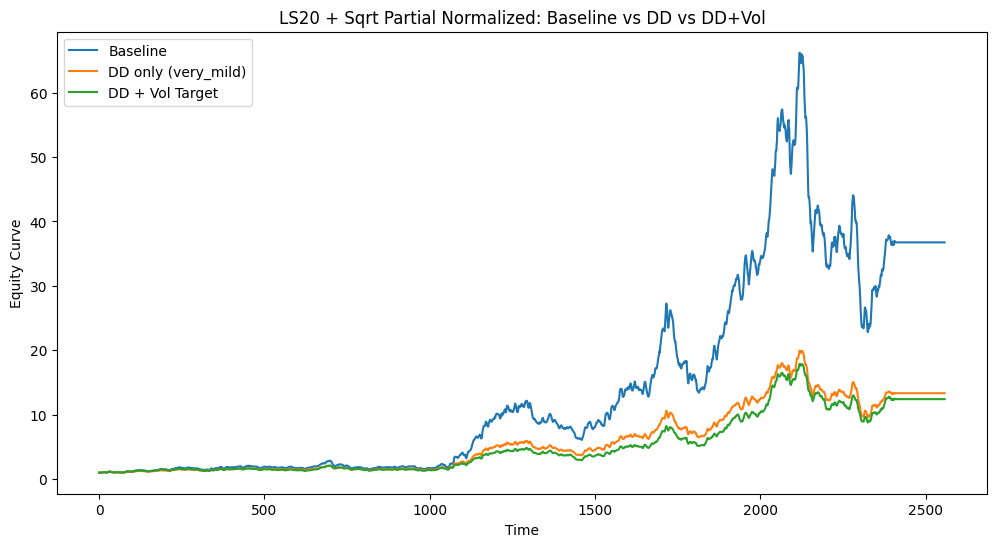

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(equity, label="Baseline")
plt.plot(equity_dd_only, label="DD only (very_mild)")
plt.plot(equity_dd_vol, label="DD + Vol Target")
plt.legend()
plt.title("LS20 + Sqrt Partial Normalized: Baseline vs DD vs DD+Vol")
plt.xlabel("Time")
plt.ylabel("Equity Curve")
plt.show()

Combining volatility targeting with the tuned drawdown overlay did not materially improve the strategy beyond drawdown control alone. Although the additional volatility layer slightly reduced maximum drawdown, it also lowered Sharpe, CAGR, and Calmar, while the equity curve remained largely a scaled-down version of the baseline path. This suggests that, in its current form, volatility targeting is acting mainly as an additional exposure reduction rather than providing a distinct risk-management benefit. As a result, the tuned very mild drawdown overlay remains the stronger and more efficient Project 05 configuration so far

**Conditional Risk Control**

In [27]:
dd = compute_drawdown(equity)

# base DD exposure (very mild)
dd_exposure = drawdown_exposure_custom(dd, [1.0, 0.90, 0.80, 0.70])

# volatility scaling
rolling_vol = returns.rolling(20).std() * np.sqrt(252)
vol_scale = (0.20 / rolling_vol).clip(0.5, 1.5)
vol_scale = vol_scale.fillna(1.0)

# CONDITION: only apply vol targeting in deep drawdown
threshold = -0.20

final_exposure_cond = dd_exposure.copy()

mask = dd <= threshold

final_exposure_cond[mask] = (
    dd_exposure[mask] * vol_scale[mask]
).clip(0.60, 1.00)

In [28]:
ret_dd_vol_cond = apply_exposure_to_return(returns, final_exposure_cond)
equity_dd_vol_cond = (1 + ret_dd_vol_cond).cumprod() 

In [29]:
ret_dd_only = apply_exposure_to_return(returns, dd_exposure)
equity_dd_only = (1 + ret_dd_only).cumprod()

comparison_best = pd.DataFrame([
    {
        "Strategy": f"{best_name}_baseline",
        "Sharpe": sharpe_ratio(returns),
        "MDD": max_drawdown(equity),
        "CAGR": compute_cagr(equity),
        "Vol": annual_vol(returns),
        "Calmar": calmar_ratio(equity),
        "Avg_Exposure": 1.0,
    },
    {
        "Strategy": f"{best_name}_dd_only",
        "Sharpe": sharpe_ratio(ret_dd_only),
        "MDD": max_drawdown(equity_dd_only),
        "CAGR": compute_cagr(equity_dd_only),
        "Vol": annual_vol(ret_dd_only),
        "Calmar": calmar_ratio(equity_dd_only),
        "Avg_Exposure": dd_exposure.shift(1).fillna(1.0).mean(),
    },
    {
        "Strategy": f"{best_name}_dd_plus_vol",
        "Sharpe": sharpe_ratio(ret_dd_vol),
        "MDD": max_drawdown(equity_dd_vol),
        "CAGR": compute_cagr(equity_dd_vol),
        "Vol": annual_vol(ret_dd_vol),
        "Calmar": calmar_ratio(equity_dd_vol),
        "Avg_Exposure": final_exposure.shift(1).fillna(1.0).mean(),
    },
    {
    "Strategy": f"{best_name}_dd_plus_vol_conditional", # applying vol targeting only where dds are high
        "Sharpe": sharpe_ratio(ret_dd_vol_cond),
        "MDD": max_drawdown(equity_dd_vol_cond),
        "CAGR": compute_cagr(equity_dd_vol_cond),
        "Vol": annual_vol(ret_dd_vol_cond),
        "Calmar": calmar_ratio(equity_dd_vol_cond),
        "Avg_Exposure": final_exposure_cond.shift(1).fillna(1.0).mean(),
    },
]).round(3)

comparison_best

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,ls_20pct_plus_sqrt_partial_normalized_baseline,1.544,-0.655,0.426,0.250,0.650,1.000
1,ls_20pct_plus_sqrt_partial_normalized_dd_only,1.544,-0.522,0.290,0.175,0.557,0.700
2,ls_20pct_plus_sqrt_partial_normalized_dd_plus_vol,1.504,-0.508,0.281,0.175,0.554,0.767
3,ls_20pct_plus_sqrt_partial_normalized_dd_plus_...,1.490,-0.513,0.279,0.176,0.544,0.735


**Smooth DD Control**

In [30]:
def drawdown_exposure_smooth(drawdown, floor=0.60, k=3.0):
    """
    Smooth exposure: higher drawdown -> gradually lower exposure.
    floor: minimum exposure
    k: curvature (higher = more aggressive)
    """

# drawdown is negative
    dd_mag = drawdown.abs()

#smooth decay: exp(-k * dd)
    exp_scale = np.exp(-k * dd_mag)

# map to [floor, 1.0]
    exposure = floor +(1 - floor) * exp_scale

    return exposure


In [31]:
dd = compute_drawdown(equity)
exp_smooth = drawdown_exposure_smooth(dd, floor=0.60, k=3.0)

ret_smooth = apply_exposure_to_return(returns, exp_smooth)
eq_smooth = (1 + ret_smooth).cumprod()

**Recovery**

In [32]:
def apply_recovery_boost(exposure, drawdown, recovery_speed=0.15):
    """
    If drawdown is improving, increase exposure slightly
    """

    dd_change = drawdown.diff() #positive = recovering

    boost = (dd_change > 0) * recovery_speed
    boosted_exposure = exposure + boost

    return boosted_exposure.clip(0.60, 1.0)

In [33]:
exp_smooth_recovery = apply_recovery_boost(exp_smooth, dd, recovery_speed=0.15)

ret_smooth_recovery = apply_exposure_to_return(returns, exp_smooth_recovery)
eq_smooth_recovery = (1 + ret_smooth_recovery).cumprod()

**Regime Filter**

In [34]:
df_regime = pd.read_csv(
    PROJECT_ROOT / "data/processed/vol_regime_calibrated_oof.csv"
)

In [35]:
# assuming you already have this from Project 02
# p_high_vol = probability of high volatility regime

def regime_exposure(p_high_vol, alpha=0.7):
    return (1 - p_high_vol) ** alpha

In [36]:
df_best = df_best.reset_index(drop=True).copy()
df_regime = df_regime.reset_index(drop=True).copy()

print("df_best:", len(df_best))
print("df_regime:", len(df_regime))

df_regime_sub = df_regime.tail(len(df_best)).reset_index(drop=True)

print("df_regime_sub:", len(df_regime_sub))

df_best["p_high_vol_calibrated"] = df_regime_sub["p_high_vol_calibrated"].values

df_best: 2558
df_regime: 2898
df_regime_sub: 2558


In [37]:
p_high_vol = df_best["p_high_vol_calibrated"]

exp_regime = regime_exposure(p_high_vol).shift(1).fillna(1.0)

exp_combined = exp_smooth * (0.5 + 0.5 * exp_regime)
exp_combined = exp_combined.clip(0.60, 1.0)

ret_combined = apply_exposure_to_return(returns, exp_combined)
eq_combined = (1 + ret_combined).cumprod()

In [38]:
df_best[["p_high_vol_calibrated"]].isna().sum()

p_high_vol_calibrated    0
dtype: int64

**Multi Strategy Allocation**

In [39]:
returns_1 = all_strategies["ls_20pct"]["portfolio_return"]
returns_2 = all_strategies["ls_20pct_plus_sqrt_partial_normalized"]["portfolio_return"]
returns_3 = all_strategies["blend_60_40_ls20_plus_ls30"]["portfolio_return"]

combined_returns = (
    0.4 * returns_1 +
    0.4 * returns_2 +
    0.2 * returns_3
).fillna(0)

eq_multi = (1 + combined_returns).cumprod()

In [40]:
dd_multi = compute_drawdown(eq_multi)
exp_multi = drawdown_exposure_smooth(dd_multi, floor=0.60)

ret_multi_dd = apply_exposure_to_return(combined_returns, exp_multi)
eq_multi_dd = (1 + ret_multi_dd).cumprod()

**Comparison**

In [41]:
comparison_best = pd.DataFrame([
    {
        "Strategy": f"{best_name}_baseline",
        "Sharpe": sharpe_ratio(returns),
        "MDD": max_drawdown(equity),
        "CAGR": compute_cagr(equity),
        "Vol": annual_vol(returns),
        "Calmar": calmar_ratio(equity),
        "Avg_Exposure": 1.0,
    },
    {
        "Strategy": f"{best_name}_dd_only",
        "Sharpe": sharpe_ratio(ret_dd_only),
        "MDD": max_drawdown(equity_dd_only),
        "CAGR": compute_cagr(equity_dd_only),
        "Vol": annual_vol(ret_dd_only),
        "Calmar": calmar_ratio(equity_dd_only),
        "Avg_Exposure": dd_exposure.shift(1).fillna(1.0).mean(),
    },
    {
        "Strategy": f"{best_name}_smooth_dd",
        "Sharpe": sharpe_ratio(ret_smooth),
        "MDD": max_drawdown(eq_smooth),
        "CAGR": compute_cagr(eq_smooth),
        "Vol": annual_vol(ret_smooth),
        "Calmar": calmar_ratio(eq_smooth),
        "Avg_Exposure": exp_smooth.shift(1).fillna(1.0).mean(),
    },
    {
        "Strategy": f"{best_name}_smooth_dd_plus_regime",
        "Sharpe": sharpe_ratio(ret_combined),
        "MDD": max_drawdown(eq_combined),
        "CAGR": compute_cagr(eq_combined),
        "Vol": annual_vol(ret_combined),
        "Calmar": calmar_ratio(eq_combined),
        "Avg_Exposure": exp_combined.shift(1).fillna(1.0).mean(),
    },
]).round(3)

comparison_best

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,ls_20pct_plus_sqrt_partial_normalized_baseline,1.544,-0.655,0.426,0.250,0.650,1.000
1,ls_20pct_plus_sqrt_partial_normalized_dd_only,1.544,-0.522,0.290,0.175,0.557,0.700
2,ls_20pct_plus_sqrt_partial_normalized_smooth_dd,1.759,-0.550,0.425,0.215,0.773,0.845
3,ls_20pct_plus_sqrt_partial_normalized_smooth_d...,1.708,-0.534,0.374,0.198,0.701,0.785


Applying a smooth, continuous drawdown-based exposure control significantly improved the risk-adjusted performance of the strategy by increasing Sharpe and Calmar while maintaining similar CAGR, whereas adding a volatility regime layer provided only marginal drawdown improvement at the cost of reduced returns and Sharpe, indicating limited incremental value.

**Tuning Smooth DD - ls_20pct_plus_sqrt_partial_normalized**

In [42]:
k_values = [2, 3, 4, 5]
floor_values = [0.55, 0.60, 0.65, 0.70]

In [43]:
tuning_results = []

for k in k_values:
    for floor in floor_values:
        
        # smooth DD exposure
        exp_smooth = drawdown_exposure_smooth(dd, floor=floor, k=k)
        
        # apply exposure
        ret_smooth = apply_exposure_to_return(returns, exp_smooth)
        eq_smooth = (1 + ret_smooth).cumprod()
        
        tuning_results.append({
            "k": k,
            "floor": floor,
            "Sharpe": sharpe_ratio(ret_smooth),
            "MDD": max_drawdown(eq_smooth),
            "CAGR": compute_cagr(eq_smooth),
            "Vol": annual_vol(ret_smooth),
            "Calmar": calmar_ratio(eq_smooth),
            "Avg_Exposure": exp_smooth.shift(1).fillna(1.0).mean(),
        })

tuning_df = pd.DataFrame(tuning_results).round(3)

In [44]:
tuning_df.sort_values(by="Sharpe", ascending=False)

,k,floor,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
12,5,0.55,1.881,-0.502,0.424,0.199,0.846,0.773
8,4,0.55,1.840,-0.516,0.425,0.204,0.824,0.795
13,5,0.60,1.839,-0.521,0.425,0.204,0.815,0.798
9,4,0.60,1.803,-0.533,0.425,0.209,0.797,0.818
14,5,0.65,1.798,-0.540,0.425,0.209,0.787,0.823
4,3,0.55,1.789,-0.535,0.425,0.211,0.795,0.825
10,4,0.65,1.768,-0.550,0.426,0.214,0.773,0.841
5,3,0.60,1.759,-0.550,0.425,0.215,0.773,0.845
15,5,0.70,1.758,-0.559,0.426,0.215,0.762,0.848
11,4,0.70,1.733,-0.567,0.426,0.219,0.751,0.864


The tuning of the smooth drawdown-based exposure control revealed that increasing the aggressiveness of the response (higher k) and allowing a lower minimum exposure (lower floor) materially improved risk-adjusted performance. In particular, configurations around k=5 and floor=0.55 delivered the strongest results, achieving a significant increase in Sharpe ratio (up to ~1.88) and Calmar ratio (~0.85) while maintaining nearly unchanged CAGR (~42–43%) and reducing maximum drawdown to approximately -50% from the baseline ~-65%. Importantly, performance remained stable across nearby parameter combinations (k=4–5, floor=0.55–0.60), indicating that the improvement is not due to a fragile parameter choice but rather a robust region of the parameter space. Overall, the results demonstrate that a smooth, continuous drawdown control can meaningfully enhance risk-adjusted returns without sacrificing long-term compounding.

**Smooth DD on Multiple Strategies**

In [45]:
BEST_K = 5
BEST_FLOOR = 0.55

strategy_base = PROJECT_ROOT / "experiments/completed/exp_004_project04_final/strategy_timeseries"

strategy_files = sorted(strategy_base.glob("*.csv"))

multi_results = []
controlled_returns = {}

for file in strategy_files:
    name = file.stem
    df = pd.read_csv(file)

    returns_i = df["portfolio_return"].fillna(0)
    equity_i = (1 + returns_i).cumprod()

    dd_i = compute_drawdown(equity_i)
    exp_i = drawdown_exposure_smooth(dd_i, floor=BEST_FLOOR, k=BEST_K)

    ret_i_dd = apply_exposure_to_return(returns_i, exp_i)
    eq_i_dd = (1 + ret_i_dd).cumprod()

    controlled_returns[name] = ret_i_dd

    multi_results.append({
        "Strategy": name,
        "Sharpe_base": sharpe_ratio(returns_i),
        "MDD_base": max_drawdown(equity_i),
        "CAGR_base": compute_cagr(equity_i),
        "Calmar_base": calmar_ratio(equity_i),
        
        "Sharpe_smooth_dd": sharpe_ratio(ret_i_dd),
        "MDD_smooth_dd": max_drawdown(eq_i_dd),
        "CAGR_smooth_dd": compute_cagr(eq_i_dd),
        "Calmar_smooth_dd": calmar_ratio(eq_i_dd),
        "Avg_Exposure": exp_i.shift(1).fillna(1.0).mean(),
    })

multi_results_df = pd.DataFrame(multi_results).round(3)

multi_results_df.sort_values(by="Sharpe_smooth_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Calmar_base,Sharpe_smooth_dd,MDD_smooth_dd,CAGR_smooth_dd,Calmar_smooth_dd,Avg_Exposure
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.650,1.881,-0.502,0.424,0.846,0.773
4,ls_20pct,1.516,-0.655,0.425,0.648,1.860,-0.502,0.424,0.845,0.773
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.600,1.852,-0.493,0.386,0.783,0.779
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.624,1.838,-0.477,0.387,0.810,0.781
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.616,1.824,-0.469,0.374,0.798,0.783
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.607,1.808,-0.461,0.362,0.785,0.786
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.548,1.805,-0.484,0.348,0.718,0.786
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.599,1.787,-0.452,0.349,0.772,0.788
6,ls_20pct_plus_pow_0.7,1.458,-0.624,0.324,0.519,1.773,-0.477,0.325,0.682,0.791
5,ls_20pct_plus_linear,1.425,-0.611,0.296,0.484,1.729,-0.467,0.297,0.636,0.798


In [46]:
multi_results_df.sort_values(by="Calmar_smooth_dd", ascending=False)

,Strategy,Sharpe_base,MDD_base,CAGR_base,Calmar_base,Sharpe_smooth_dd,MDD_smooth_dd,CAGR_smooth_dd,Calmar_smooth_dd,Avg_Exposure
9,ls_20pct_plus_sqrt_partial_normalized,1.544,-0.655,0.426,0.650,1.881,-0.502,0.424,0.846,0.773
4,ls_20pct,1.516,-0.655,0.425,0.648,1.860,-0.502,0.424,0.845,0.773
3,blend_70_30_ls20_plus_ls30,1.515,-0.625,0.390,0.624,1.838,-0.477,0.387,0.810,0.781
2,blend_60_40_ls20_plus_ls30,1.510,-0.614,0.378,0.616,1.824,-0.469,0.374,0.798,0.783
1,blend_50_50_ls20_plus_ls30,1.503,-0.604,0.366,0.607,1.808,-0.461,0.362,0.785,0.786
8,ls_20pct_plus_sqrt_partial,1.520,-0.644,0.386,0.600,1.852,-0.493,0.386,0.783,0.779
0,blend_40_60_ls20_plus_ls30,1.493,-0.593,0.355,0.599,1.787,-0.452,0.349,0.772,0.788
7,ls_20pct_plus_sqrt,1.482,-0.633,0.347,0.548,1.805,-0.484,0.348,0.718,0.786
11,ls_30pct_plus_sqrt_partial_norm,1.451,-0.549,0.309,0.563,1.691,-0.420,0.300,0.714,0.796
10,ls_30pct,1.418,-0.549,0.307,0.559,1.663,-0.420,0.299,0.711,0.797


Applying the optimized smooth drawdown control across multiple strategies demonstrated consistent improvements in risk-adjusted performance, and combining selectively diversified strategies is expected to further enhance stability by reducing correlation-driven drawdowns without materially sacrificing long-term returns.

**Blending strategies - Equal weights**

One thing to remember here is we are not blending independent strategies but highly correlated variations of the same alpha

In [47]:

import json
import sqlite3

db_path = PROJECT_ROOT / "storage/quant_lab.db"
conn = sqlite3.connect(db_path)

In [48]:
config = json.loads(
    pd.read_sql("""
    SELECT config_json
    FROM configs
    WHERE experiment_id = 'exp_005_risk_engine_final'
    """, conn).loc[0, "config_json"]
)

weights = config["weights"]
selected = list(weights.keys())

In [49]:
multi_ret = pd.concat(
    [controlled_returns[s] for s in selected],
    axis=1
).mean(axis=1)

multi_eq = (1 + multi_ret).cumprod()

In [50]:
multi_summary = pd.DataFrame([{
    "Strategy": "Multi-strategy + smooth DD",
    "Sharpe": sharpe_ratio(multi_ret),
    "MDD": max_drawdown(multi_eq),
    "CAGR": compute_cagr(multi_eq),
    "Vol": annual_vol(multi_ret),
    "Calmar": calmar_ratio(multi_eq),
}]).round(3)

multi_summary

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,Multi-strategy + smooth DD,1.826,-0.464,0.366,0.18,0.789


**Blending Weighted Portfolio**

In [51]:
config = json.loads(
    pd.read_sql("""
    SELECT config_json
    FROM configs
    WHERE experiment_id = 'exp_005_risk_engine_final'
    """, conn).loc[0, "config_json"]
)

weights = config["weights"]
selected = list(weights.keys())

In [52]:
# build weighted portfolio
df_multi = pd.concat(
    [controlled_returns[s] for s in selected],
    axis=1
)

df_multi.columns = selected  # name columns

# apply weights
multi_ret = sum(df_multi[col] * weights[col] for col in selected)

multi_eq = (1 + multi_ret).cumprod()

In [53]:
multi_summary = pd.DataFrame([{
    "Strategy": "Multi-strategy + smooth DD",
    "Sharpe": sharpe_ratio(multi_ret),
    "MDD": max_drawdown(multi_eq),
    "CAGR": compute_cagr(multi_eq),
    "Vol": annual_vol(multi_ret),
    "Calmar": calmar_ratio(multi_eq),
}]).round(3)

multi_summary

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar
0,Multi-strategy + smooth DD,1.851,-0.476,0.384,0.185,0.807


Introducing a weighted multi-strategy allocation preserved the strength of the primary alpha while benefiting from diversification, resulting in improved CAGR relative to equal-weighting and reduced drawdown compared to the single-strategy approach, achieving a well-balanced and robust portfolio.

**Portfolio level DD control**

In [54]:
# Portfolio-level drawdown
portfolio_dd = compute_drawdown(multi_eq)

# Apply same tuned smooth DD rule at portfolio level
portfolio_exp = drawdown_exposure_smooth(
    portfolio_dd,
    floor=0.55,
    k=5
)

# Apply exposure to combined portfolio returns
multi_ret_portfolio_dd = apply_exposure_to_return(multi_ret, portfolio_exp)
multi_eq_portfolio_dd = (1 + multi_ret_portfolio_dd).cumprod()

In [55]:
portfolio_dd_summary = pd.DataFrame([
    {
        "Strategy": "Weighted multi-strategy + smooth DD",
        "Sharpe": sharpe_ratio(multi_ret),
        "MDD": max_drawdown(multi_eq),
        "CAGR": compute_cagr(multi_eq),
        "Vol": annual_vol(multi_ret),
        "Calmar": calmar_ratio(multi_eq),
        "Avg_Exposure": 1.0,
    },
    {
        "Strategy": "Weighted multi-strategy + strategy DD + portfolio DD",
        "Sharpe": sharpe_ratio(multi_ret_portfolio_dd),
        "MDD": max_drawdown(multi_eq_portfolio_dd),
        "CAGR": compute_cagr(multi_eq_portfolio_dd),
        "Vol": annual_vol(multi_ret_portfolio_dd),
        "Calmar": calmar_ratio(multi_eq_portfolio_dd),
        "Avg_Exposure": portfolio_exp.shift(1).fillna(1.0).mean(),
    },
]).round(3)

portfolio_dd_summary

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,Weighted multi-strategy + smooth DD,1.851,-0.476,0.384,0.185,0.807,1.000
1,Weighted multi-strategy + strategy DD + portfo...,2.090,-0.367,0.377,0.159,1.026,0.797


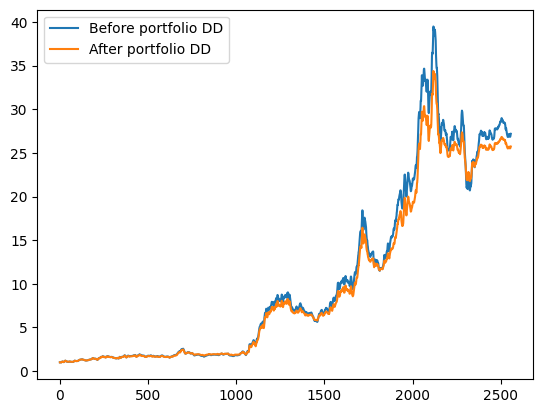

In [56]:
plt.plot(multi_eq, label="Before portfolio DD")
plt.plot(multi_eq_portfolio_dd, label="After portfolio DD")
plt.legend()

The portfolio-level drawdown control successfully reduces downside volatility and drawdowns while preserving the overall structure and recovery dynamics of the equity curve, indicating effective risk control without materially degrading the underlying signal.

**STACK**

Signal (Project 4)

           |

Strategy construction

           |

Strategy-level DD control

           |

Portfolio weighting

           |

Portfolio-level DD control

In [57]:
out_dir = PROJECT_ROOT / "experiments/completed/exp_005_risk_engine_final"
out_dir.mkdir(parents=True, exist_ok=True)

portfolio_dd_summary.to_csv(out_dir / "final_project05_summary.csv", index=False)

pd.DataFrame({
    "portfolio_return": multi_ret_portfolio_dd,
    "equity_curve": multi_eq_portfolio_dd,
    "portfolio_dd_exposure": portfolio_exp.shift(1).fillna(1.0),
}).to_csv(out_dir / "final_weighted_multi_strategy_portfolio_dd.csv", index=False)

multi_results_df.to_csv(out_dir / "all_strategies_smooth_dd_results.csv", index=False)

In [58]:
import json

config = {
    "project": "Project 05 Risk Engine",
    "final_model": "weighted_multi_strategy_with_strategy_and_portfolio_smooth_dd",
    "strategy_level_dd": {
        "method": "smooth_drawdown_exposure",
        "k": 5,
        "floor": 0.55
    },
    "portfolio_level_dd": {
        "method": "smooth_drawdown_exposure",
        "k": 5,
        "floor": 0.55
    },
    "weights": {
        "ls_20pct_plus_sqrt_partial_normalized": 0.5,
        "blend_60_40_ls20_plus_ls30": 0.3,
        "ls_30pct": 0.2
    }
}

with open(out_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

In [59]:
import sqlite3

db_path = PROJECT_ROOT / "storage/quant_lab.db"
conn = sqlite3.connect(db_path)

print("DB created at:", db_path)

DB created at: /Users/rawls/quant-lab/storage/quant_lab.db


**Create Tables - SQL**

In [60]:
cursor = conn.cursor()

cursor.execute("""
               CREATE TABLE IF NOT EXISTS experiments (
               experiment_id TEXT PRIMARY KEY,
               project TEXT,
               desciption TEXT,
               created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
               )
               """)

cursor.execute("""
               CREATE TABLE IF NOT EXISTS stratrgy_metrics (
               experiment_id TEXT,
               strategy TEXT,
               sharpe REAL,
               cagr REAL,
               vol REAL,
               calmar REAL,
               avg_exposure REAL,
               PRIMARY KEY (experiment_id, strategy)
               )
               """)

cursor.execute("""
               CREATE TABLE IF NOT EXISTS portfolio_timeseries (
               experiment_id TEXT,
               date TEXT,
               portfolio_return REAL,
               equity_curve REAL,
               exposure REAL)
               """)

cursor.execute("""
               CREATE TABLE IF NOT EXISTS configs (
               experiment_id TEXT PRIMARY KEY,
               config_json TEXT
               )
               """)

conn.commit()

**Insert Project 05 Experiment Metadata**

In [61]:
exp_id = "exp_005_risk_engine_final"

cursor.execute("""
               INSERT OR REPLACE INTO experiments (experiment_id, project, desciption)
               VALUES (?, ?, ?)
               """, (
                   exp_id,
                   "Project 05 Risk Engine",
                   "Weighted multi-strategy portfolio with strategy-level and portfolio-level smooth drawdown control"

               ))

conn.commit()

**Insert final Metrics**

In [62]:
metrics_path = PROJECT_ROOT / "experiments/completed/exp_005_risk_engine_final/final_project05_summary.csv"
df_metrics = pd.read_csv(metrics_path)

df_metrics = df_metrics.rename(columns={
    "Strategy": "strategy",
    "Sharpe": "sharpe",
    "MDD": "mdd",
    "CAGR": "cagr",
    "Vol": "vol",
    "Calmar": "calmar",
    "Avg_Exposure": "avg_exposure"
})
df_metrics["experiment_id"] = exp_id

df_metrics = df_metrics[
    ["experiment_id", "strategy", "sharpe", "mdd", "cagr", "vol", "calmar", "avg_exposure"]
]

cursor.execute(
    "DELETE FROM strategy_metrics WHERE experiment_id = ?",
    (exp_id,)
)
conn.commit()

df_metrics.to_sql("strategy_metrics", conn, if_exists="append", index=False)

2

In [63]:
print(df_metrics.columns.tolist())
df_metrics.head() # this a dataframe - from memory

['experiment_id', 'strategy', 'sharpe', 'mdd', 'cagr', 'vol', 'calmar', 'avg_exposure']


,experiment_id,strategy,sharpe,mdd,cagr,vol,calmar,avg_exposure
0,exp_005_risk_engine_final,Weighted multi-strategy + smooth DD,1.851,-0.476,0.384,0.185,0.807,1.000
1,exp_005_risk_engine_final,Weighted multi-strategy + strategy DD + portfo...,2.090,-0.367,0.377,0.159,1.026,0.797


In [64]:
pd.read_sql("SELECT * FROM strategy_metrics", conn) #this read from database

,experiment_id,strategy,sharpe,mdd,cagr,vol,calmar,avg_exposure
0,auto_smooth_dd_k2_floor0_55,smooth_dd_k2_floor0.55,1.971682,-0.415125,NaN,0.171133,0.916405,0.889575
1,auto_smooth_dd_k2_floor0_6,smooth_dd_k2_floor0.6,1.958068,-0.422165,NaN,0.172615,0.902162,0.901844
2,auto_smooth_dd_k2_floor0_65,smooth_dd_k2_floor0.65,1.944502,-0.429128,NaN,0.174113,0.888530,0.914114
3,auto_smooth_dd_k2_floor0_7,smooth_dd_k2_floor0.7,1.930991,-0.436015,NaN,0.175628,0.875471,0.926383
4,auto_smooth_dd_k3_floor0_7,smooth_dd_k3_floor0.7,1.960942,-0.422990,NaN,0.172316,0.900278,0.901028
5,auto_smooth_dd_k4_floor0_7,smooth_dd_k4_floor0.7,1.986194,-0.413024,NaN,0.169606,0.920097,0.880865
6,auto_smooth_dd_k5_floor0_7,smooth_dd_k5_floor0.7,2.007699,-0.405331,NaN,0.167349,0.935841,0.864652
7,auto_smooth_dd_k3_floor0_5,smooth_dd_k3_floor0.5,2.036557,-0.385155,NaN,0.164390,0.982341,0.835047
8,auto_smooth_dd_k3_floor0_55,smooth_dd_k3_floor0.55,2.017533,-0.394820,NaN,0.166326,0.959894,0.851542
9,auto_smooth_dd_k3_floor0_6,smooth_dd_k3_floor0.6,1.998576,-0.404347,NaN,0.168293,0.938812,0.868037


**Insert Final Portfolio Time Series**

In [65]:
ts_path = PROJECT_ROOT / "experiments/completed/exp_005_risk_engine_final/final_weighted_multi_strategy_portfolio_dd.csv"

df_ts = pd.read_csv(ts_path)

df_ts["experiment_id"] = exp_id

if "Date" not in df_ts.columns and "date" not in df_ts.columns:
    df_ts["date"] = df_ts.index.astype(str)

df_ts = df_ts.rename(columns={
    "Date": "date",
    "portfolio_dd_exposure": "exposure"
})

df_ts = df_ts[
    ["experiment_id", "date", "portfolio_return", "equity_curve", "exposure"]
]

cursor.execute(
    "DELETE FROM portfolio_timeseries WHERE experiment_id = ?",
    (exp_id,)
)
conn.commit()

df_ts.to_sql("portfolio_timeseries", conn, if_exists="append", index=False)

2558

In [66]:
config_path = PROJECT_ROOT / "experiments/completed/exp_005_risk_engine_final/config.json"

with open(config_path, "r") as f:
    config_json = json.dumps(json.load(f))

cursor.execute("""
               INSERT OR REPLACE INTO configs (experiment_id, config_json)
               VALUES (?, ?)
               """, (exp_id, config_json))


conn.commit()

**Verifying Inserts**

In [67]:
pd.read_sql("SELECT * FROM experiments", conn)

,experiment_id,project,desciption,created_at
0,auto_smooth_dd_k2_floor0_55,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
1,auto_smooth_dd_k2_floor0_6,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
2,auto_smooth_dd_k2_floor0_65,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
3,auto_smooth_dd_k2_floor0_7,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
4,auto_smooth_dd_k3_floor0_7,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
5,auto_smooth_dd_k4_floor0_7,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
6,auto_smooth_dd_k5_floor0_7,Project 05 Auto Experiments,NaN,2026-05-03 01:52:41
7,auto_smooth_dd_k3_floor0_5,Project 05 Auto Experiments,NaN,2026-05-03 01:52:55
8,auto_smooth_dd_k3_floor0_55,Project 05 Auto Experiments,NaN,2026-05-03 01:52:55
9,auto_smooth_dd_k3_floor0_6,Project 05 Auto Experiments,NaN,2026-05-03 01:52:55


In [68]:
pd.read_sql("SELECT * FROM strategy_metrics", conn)

,experiment_id,strategy,sharpe,mdd,cagr,vol,calmar,avg_exposure
0,auto_smooth_dd_k2_floor0_55,smooth_dd_k2_floor0.55,1.971682,-0.415125,NaN,0.171133,0.916405,0.889575
1,auto_smooth_dd_k2_floor0_6,smooth_dd_k2_floor0.6,1.958068,-0.422165,NaN,0.172615,0.902162,0.901844
2,auto_smooth_dd_k2_floor0_65,smooth_dd_k2_floor0.65,1.944502,-0.429128,NaN,0.174113,0.888530,0.914114
3,auto_smooth_dd_k2_floor0_7,smooth_dd_k2_floor0.7,1.930991,-0.436015,NaN,0.175628,0.875471,0.926383
4,auto_smooth_dd_k3_floor0_7,smooth_dd_k3_floor0.7,1.960942,-0.422990,NaN,0.172316,0.900278,0.901028
5,auto_smooth_dd_k4_floor0_7,smooth_dd_k4_floor0.7,1.986194,-0.413024,NaN,0.169606,0.920097,0.880865
6,auto_smooth_dd_k5_floor0_7,smooth_dd_k5_floor0.7,2.007699,-0.405331,NaN,0.167349,0.935841,0.864652
7,auto_smooth_dd_k3_floor0_5,smooth_dd_k3_floor0.5,2.036557,-0.385155,NaN,0.164390,0.982341,0.835047
8,auto_smooth_dd_k3_floor0_55,smooth_dd_k3_floor0.55,2.017533,-0.394820,NaN,0.166326,0.959894,0.851542
9,auto_smooth_dd_k3_floor0_6,smooth_dd_k3_floor0.6,1.998576,-0.404347,NaN,0.168293,0.938812,0.868037


In [69]:
pd.read_sql("""
            SELECT *
            FROM portfolio_timeseries
            WHERE experiment_id = 'exp_005_risk_engine_final'
            LIMIT 5
            """, conn)

,experiment_id,date,portfolio_return,equity_curve,exposure
0,exp_005_risk_engine_final,0,0.002917,1.002917,1.000000
1,exp_005_risk_engine_final,1,0.005973,1.008908,1.000000
2,exp_005_risk_engine_final,2,-0.002303,1.006585,1.000000
3,exp_005_risk_engine_final,3,-0.000840,1.005739,0.994849
4,exp_005_risk_engine_final,4,-0.008182,0.997511,0.992980


In [70]:
# Best strategy variant in Project 05
pd.read_sql("""
SELECT strategy, sharpe, mdd, cagr, calmar
FROM strategy_metrics
WHERE experiment_id = 'exp_005_risk_engine_final'
ORDER BY calmar DESC
""", conn)

,strategy,sharpe,mdd,cagr,calmar
0,Weighted multi-strategy + strategy DD + portfo...,2.090,-0.367,0.377,1.026
1,Weighted multi-strategy + smooth DD,1.851,-0.476,0.384,0.807


In [71]:
# Final equity value from stored time series
pd.read_sql("""
SELECT 
    experiment_id,
    MAX(CAST(date AS INTEGER)) AS last_step,
    equity_curve AS final_equity
FROM portfolio_timeseries
WHERE experiment_id = 'exp_005_risk_engine_final'
ORDER BY CAST(date AS INTEGER) DESC
LIMIT 1
""", conn)

,experiment_id,last_step,final_equity
0,exp_005_risk_engine_final,2557,25.725076


In [72]:
# Check stored config
pd.read_sql("""
SELECT config_json
FROM configs
WHERE experiment_id = 'exp_005_risk_engine_final'
""", conn)

,config_json
0,"{""project"": ""Project 05 Risk Engine"", ""final_m..."


In [73]:
top_strategy_df = pd.read_sql("""
SELECT 
    strategy,
    sharpe,
    mdd,
    cagr,
    calmar
FROM strategy_metrics
WHERE experiment_id = 'exp_005_risk_engine_final'
ORDER BY calmar DESC
LIMIT 1
""", conn)

top_strategy_df

,strategy,sharpe,mdd,cagr,calmar
0,Weighted multi-strategy + strategy DD + portfo...,2.09,-0.367,0.377,1.026


In [74]:
best_strategy_from_db = top_strategy_df.loc[0, "strategy"]
best_strategy_from_db

'Weighted multi-strategy + strategy DD + portfolio DD'

In [75]:
def get_top_strategies(conn, experiment_id, metric="calmar", limit=3):
    allowed_metrics = {"sharpe", "mdd", "cagr", "vol", "calmar", "avg_exposure"}
    
    if metric not in allowed_metrics:
        raise ValueError(f"metric must be one of {allowed_metrics}")
    
    query = f"""
    SELECT 
        strategy,
        sharpe,
        mdd,
        cagr,
        vol,
        calmar,
        avg_exposure
    FROM strategy_metrics
    WHERE experiment_id = ?
    ORDER BY {metric} DESC
    LIMIT ?
    """
    
    return pd.read_sql(query, conn, params=(experiment_id, limit))

In [76]:
# By Calmar
get_top_strategies(
    conn,
    experiment_id="exp_005_risk_engine_final",
    metric="calmar",
    limit=2
)

,strategy,sharpe,mdd,cagr,vol,calmar,avg_exposure
0,Weighted multi-strategy + strategy DD + portfo...,2.090,-0.367,0.377,0.159,1.026,0.797
1,Weighted multi-strategy + smooth DD,1.851,-0.476,0.384,0.185,0.807,1.000


In [77]:
# By Sharpe
get_top_strategies(
    conn,
    experiment_id="exp_005_risk_engine_final",
    metric="sharpe",
    limit=2
)


,strategy,sharpe,mdd,cagr,vol,calmar,avg_exposure
0,Weighted multi-strategy + strategy DD + portfo...,2.090,-0.367,0.377,0.159,1.026,0.797
1,Weighted multi-strategy + smooth DD,1.851,-0.476,0.384,0.185,0.807,1.000


In [78]:
selected_strategies = get_top_strategies(
    conn,
    experiment_id="exp_005_risk_engine_final",
    metric="calmar",
    limit=3
)["strategy"].tolist()

selected_strategies

['Weighted multi-strategy + strategy DD + portfolio DD',
 'Weighted multi-strategy + smooth DD']

In [79]:
import json

config_df = pd.read_sql("""
SELECT config_json
FROM configs
WHERE experiment_id = 'exp_005_risk_engine_final'
""", conn)

config_json_str = config_df.loc[0, "config_json"]
config = json.loads(config_json_str)

config

{'project': 'Project 05 Risk Engine',
 'final_model': 'weighted_multi_strategy_with_strategy_and_portfolio_smooth_dd',
 'strategy_level_dd': {'method': 'smooth_drawdown_exposure',
  'k': 5,
  'floor': 0.55},
 'portfolio_level_dd': {'method': 'smooth_drawdown_exposure',
  'k': 5,
  'floor': 0.55},
 'weights': {'ls_20pct_plus_sqrt_partial_normalized': 0.5,
  'blend_60_40_ls20_plus_ls30': 0.3,
  'ls_30pct': 0.2}}

**Load config from DB**

In [80]:
import json

config_df = pd.read_sql("""
SELECT config_json
FROM configs
WHERE experiment_id = 'exp_005_risk_engine_final'
""", conn)

config = json.loads(config_df.loc[0, "config_json"])

In [81]:
weights = config["weights"]
selected = list(weights.keys())

In [82]:
print(selected)
print(weights)

['ls_20pct_plus_sqrt_partial_normalized', 'blend_60_40_ls20_plus_ls30', 'ls_30pct']
{'ls_20pct_plus_sqrt_partial_normalized': 0.5, 'blend_60_40_ls20_plus_ls30': 0.3, 'ls_30pct': 0.2}


**Auto Select The Best Experiment**

In [83]:
# 1) Load base portfolio weights
base_exp_id = "exp_005_risk_engine_final"

base_config_df = pd.read_sql("""
SELECT config_json
FROM configs
WHERE experiment_id = ?
""", conn, params=(base_exp_id,))

base_config = json.loads(base_config_df.loc[0, "config_json"])

weights = base_config["weights"]
selected = list(weights.keys())

In [84]:
# 2) Build base weighted portfolio
df_multi = pd.concat(
    [controlled_returns[s] for s in selected],
    axis=1
)

df_multi.columns = selected

multi_ret = sum(df_multi[col] * weights[col] for col in selected)
multi_eq = (1 + multi_ret).cumprod()

In [85]:
import re

def extract_k_floor(exp_id):
    match = re.search(r"_k(\d+)_floor([0-9_]+)", exp_id)
    if not match:
        return None, None

    k = float(match.group(1))
    floor = float(match.group(2).replace("_", "."))
    return k, floor

In [86]:
# 3) Get best DD parameter experiment
best_param = pd.read_sql("""
SELECT experiment_id, calmar
FROM strategy_metrics
WHERE experiment_id LIKE 'auto_smooth_dd_%'
ORDER BY calmar DESC
LIMIT 1
""", conn)

best_exp_id = best_param.loc[0, "experiment_id"]

k, floor = extract_k_floor(best_exp_id)
k, floor

(6.0, 0.5)

In [87]:
# 4) Apply best DD overlay
portfolio_dd = compute_drawdown(multi_eq)

portfolio_exp = drawdown_exposure_smooth(
    portfolio_dd,
    floor=floor,
    k=k
)

multi_ret_final = apply_exposure_to_return(multi_ret, portfolio_exp)
multi_eq_final = (1 + multi_ret_final).cumprod()

In [88]:
# 5) Evaluate final result
final_summary = pd.DataFrame([{
    "Strategy": "Final Portfolio: DB weights + best DD params",
    "k": k,
    "floor": floor,
    "Sharpe": sharpe_ratio(multi_ret_final),
    "MDD": max_drawdown(multi_eq_final),
    "CAGR": compute_cagr(multi_eq_final),
    "Vol": annual_vol(multi_ret_final),
    "Calmar": calmar_ratio(multi_eq_final),
    "Avg_Exposure": portfolio_exp.shift(1).fillna(1.0).mean()
}]).round(3)

final_summary

,Strategy,k,floor,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,Final Portfolio: DB weights + best DD params,6.0,0.5,2.151,-0.343,0.375,0.154,1.093,0.752


In [89]:
# 4) Apply best DD overlay
portfolio_dd = compute_drawdown(multi_eq)

portfolio_exp = drawdown_exposure_smooth(
    portfolio_dd,
    floor=floor,
    k=k
)

multi_ret_final = apply_exposure_to_return(multi_ret, portfolio_exp)
multi_eq_final = (1 + multi_ret_final).cumprod()

**Apply Portfolio-level DD to the DB reconstructed Portfolio**

In [90]:
portfolio_dd = compute_drawdown(multi_eq)


portfolio_exp = drawdown_exposure_smooth(
    portfolio_dd,
    floor=0.55,
    k=5
)

multi_ret_portfolio_dd = apply_exposure_to_return(multi_ret, portfolio_exp)
multi_eq_portfolio_dd = (1 + multi_ret_portfolio_dd).cumprod()

In [91]:
# 5) Evaluate final result
final_summary = pd.DataFrame([{
    "Strategy": "Final Portfolio: DB weights + best DD params",
    "k": k,
    "floor": floor,
    "Sharpe": sharpe_ratio(multi_ret_final),
    "MDD": max_drawdown(multi_eq_final),
    "CAGR": compute_cagr(multi_eq_final),
    "Vol": annual_vol(multi_ret_final),
    "Calmar": calmar_ratio(multi_eq_final),
    "Avg_Exposure": portfolio_exp.shift(1).fillna(1.0).mean()
}]).round(3)

final_summary

,Strategy,k,floor,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,Final Portfolio: DB weights + best DD params,6.0,0.5,2.151,-0.343,0.375,0.154,1.093,0.797


In [92]:
multi_exp_portfolio_dd_summary = pd.DataFrame([{
    "Strategy": "DB-selected multi-experiment portfolio + portfolio DD",
    "Sharpe": sharpe_ratio(multi_ret_portfolio_dd),
    "MDD": max_drawdown(multi_eq_portfolio_dd),
    "CAGR": compute_cagr(multi_eq_portfolio_dd),
    "Vol": annual_vol(multi_ret_portfolio_dd),
    "Calmar": calmar_ratio(multi_eq_portfolio_dd),
    "Avg_Exposure": portfolio_exp.shift(1).fillna(1.0).mean()
}]).round(3)

multi_exp_portfolio_dd_summary

,Strategy,Sharpe,MDD,CAGR,Vol,Calmar,Avg_Exposure
0,DB-selected multi-experiment portfolio + portf...,2.09,-0.367,0.377,0.159,1.026,0.797


**Store This as New Experiment**

In [93]:
new_exp_id = "exp_006_multi_experiment_ensemble"

In [94]:
cursor.execute("""
INSERT OR REPLACE INTO experiments (experiment_id, project)
VALUES (?, ?)
""", (
    new_exp_id,
    "Project 05 Risk Engine"
))

conn.commit()

In [95]:

#store metrics

df_metrics = multi_exp_portfolio_dd_summary.copy()
df_metrics["experiment_id"] = new_exp_id

df_metrics = df_metrics.rename(columns={
    "Strategy": "strategy",
    "Sharpe": "sharpe",
    "MDD": "mdd",
    "CAGR": "cagr",
    "Vol": "vol",
    "Calmar": "calmar",
    "Avg_Exposure": "avg_exposure"
})

df_metrics = df_metrics[
    ["experiment_id", "strategy", "sharpe", "mdd", "cagr", "vol", "calmar", "avg_exposure"]
]

# delete old if exists
cursor.execute("DELETE FROM strategy_metrics WHERE experiment_id = ?", (new_exp_id,))
conn.commit()

df_metrics.to_sql("strategy_metrics", conn, if_exists="append", index=False)

1

In [96]:
# store time series

df_ts = pd.DataFrame({
    "experiment_id": new_exp_id,
    "date": multi_eq_portfolio_dd.index.astype(str),
    "portfolio_return": multi_ret_portfolio_dd.values,
    "equity_curve": multi_eq_portfolio_dd.values,
    "exposure": portfolio_exp.shift(1).fillna(1.0).values
})

cursor.execute("DELETE FROM portfolio_timeseries WHERE experiment_id = ?", (new_exp_id,))
conn.commit()

df_ts.to_sql("portfolio_timeseries", conn, if_exists="append", index=False)

2558

In [97]:
# only use portfolio experiments
top_exps = pd.read_sql("""
SELECT 
    experiment_id,
    MAX(calmar) AS best_calmar
FROM strategy_metrics
WHERE experiment_id NOT LIKE 'auto_smooth_dd_%'
GROUP BY experiment_id
ORDER BY best_calmar DESC
LIMIT 3
""", conn)

top_experiment_ids = top_exps["experiment_id"].tolist()

In [98]:
# # store config

# ensemble_config = {
#     "type": "multi_experiment_ensemble",
#     "source_experiments": top_experiment_ids,
#     "combined_weights": combined_weights,
#     "portfolio_level_dd": {
#         "method": "smooth_drawdown_exposure",
#         "k": 5,
#         "floor": 0.55
#     }
# }

# cursor.execute("""
# INSERT OR REPLACE INTO configs (experiment_id, config_json)
# VALUES (?, ?)
# """, (new_exp_id, json.dumps(ensemble_config)))

# conn.commit()

**Automated Experiment Generation**

automated experiment generation let the system create and test many research variants systematically instead of manually coding each one

In [99]:
#define ranges

k_values = [3, 4, 5, 6]
floor_values = [0.50, 0.55, 0.60, 0.65]

In [100]:
# build grid automatically

experiment_grid = [
    {"k": k, "floor": floor}
    for k in k_values
    for floor in floor_values
]

In [101]:
# functions to run one experiment

def run_smooth_dd_experiment(exp_id, k, floor, returns):
    equity = (1 + returns).cumprod()

    dd = compute_drawdown(equity)
    exposure = drawdown_exposure_smooth(dd, floor=floor, k=k)

    ret_dd = apply_exposure_to_return(returns, exposure)
    eq_dd = (1 + ret_dd).cumprod()

    metrics = {
        "experiment_id": exp_id,
        "strategy": f"smooth_dd_k{k}_floor{floor}",
        "sharpe": sharpe_ratio(ret_dd),
        "mdd": max_drawdown(eq_dd),
        "vol": annual_vol(ret_dd),
        "calmar": calmar_ratio(eq_dd),
        "avg_exposure": exposure.shift(1).fillna(1.0).mean(),
    }

    ts = pd.DataFrame({
        "experiment_id": exp_id,
        "date": ret_dd.index.astype(str),
        "portfolio_return": ret_dd.values,
        "equity_curve": eq_dd.values,
        "exposure": exposure.shift(1).fillna(1.0).mean(),
    })

    config = {
        "type": "auto_generated_smooth_dd",
        "k": k,
        "floor": floor,
        "base_strategy": best_name,
    }

    return metrics, ts, config

In [102]:
# Run and store experiments
for params in experiment_grid:
    k = params["k"]
    floor = params["floor"]

    exp_id = f"auto_smooth_dd_k{k}_floor{str(floor).replace('.', '_')}"

    metrics, ts, config = run_smooth_dd_experiment(
        exp_id=exp_id,
        k=k,
        floor=floor,
        returns=multi_ret
    )

    cursor.execute("""
                   INSERT OR REPLACE INTO experiments (experiment_id, project)
                   VALUES (?, ?)
                   """, (exp_id, "Project 05 Auto Experiments"))
    
    cursor.execute("DELETE FROM strategy_metrics WHERE experiment_id = ?", (exp_id,))
    cursor.execute("DELETE FROM portfolio_timeseries WHERE experiment_id = ?", (exp_id,))

    pd.DataFrame([metrics]).to_sql(
        "strategy_metrics",
        conn,
        if_exists="append",
        index=False
    )

    ts.to_sql(
        "portfolio_timeseries",
        conn,
        if_exists="append",
        index=False
    )

    cursor.execute("""
                   INSERT OR REPLACE INTO configs (experiment_id, config_json)
                   VALUES (?, ?)
                   """, (exp_id, json.dumps(config)))
    
    conn.commit()

In [103]:
#order best generated experiment

pd.read_sql("""
            SELECT 
            experiment_id,
            strategy,
            sharpe,
            mdd,
            vol,
            calmar,
            avg_exposure
            FROM strategy_metrics
            WHERE experiment_id LIKE 'auto_smooth_dd_%'
            ORDER BY calmar DESC
            """, conn)

,experiment_id,strategy,sharpe,mdd,vol,calmar,avg_exposure
0,auto_smooth_dd_k6_floor0_5,smooth_dd_k6_floor0.5,2.150732,-0.342826,0.153580,1.092532,0.752447
1,auto_smooth_dd_k5_floor0_5,smooth_dd_k5_floor0.5,2.117922,-0.353660,0.156567,1.062269,0.774421
2,auto_smooth_dd_k6_floor0_55,smooth_dd_k6_floor0.55,2.119256,-0.357393,0.156440,1.051015,0.777202
3,auto_smooth_dd_k5_floor0_55,smooth_dd_k5_floor0.55,2.090113,-0.366949,0.159175,1.026370,0.796979
4,auto_smooth_dd_k4_floor0_5,smooth_dd_k4_floor0.5,2.080245,-0.367453,0.160111,1.025815,0.801442
5,auto_smooth_dd_k6_floor0_6,smooth_dd_k6_floor0.6,2.087952,-0.371663,0.159373,1.013488,0.801958
6,auto_smooth_dd_k4_floor0_55,smooth_dd_k4_floor0.55,2.056551,-0.379139,0.162417,0.996298,0.821298
7,auto_smooth_dd_k5_floor0_6,smooth_dd_k5_floor0.6,2.062434,-0.379989,0.161843,0.993577,0.819537
8,auto_smooth_dd_k3_floor0_5,smooth_dd_k3_floor0.5,2.036557,-0.385155,0.164390,0.982341,0.835047
9,auto_smooth_dd_k6_floor0_65,smooth_dd_k6_floor0.65,2.056904,-0.385642,0.162374,0.979407,0.826713


In [104]:
df = pd.read_sql("""
SELECT 
    CAST(
        substr(
            experiment_id,
            instr(experiment_id, '_k') + 2,
            instr(experiment_id, '_floor') - (instr(experiment_id, '_k') + 2)
        ) AS INTEGER
    ) AS k,

    CAST(
        REPLACE(
            substr(experiment_id, instr(experiment_id, '_floor') + 6),
            '_',
            '.'
        ) AS FLOAT
    ) AS floor,

    calmar

FROM strategy_metrics
WHERE experiment_id LIKE 'auto_smooth_dd_%'
""", conn)

df

,k,floor,calmar
0,2,0.55,0.916405
1,2,0.60,0.902162
2,2,0.65,0.888530
3,2,0.70,0.875471
4,3,0.70,0.900278
5,4,0.70,0.920097
6,5,0.70,0.935841
7,3,0.50,0.982341
8,3,0.55,0.959894
9,3,0.60,0.938812


In [105]:
df.columns

Index(['k', 'floor', 'calmar'], dtype='str')

In [106]:
#pivot Table

pivot = df.pivot_table(
    index="k",
    columns="floor",
    values="calmar",
    aggfunc="mean"   # or "max"
)

pivot

floor,0.50,0.55,0.60,0.65,0.70
k,,,,,
2,NaN,0.916405,0.902162,0.888530,0.875471
3,0.982341,0.959894,0.938812,0.918975,0.900278
4,1.025815,0.996298,0.968991,0.943659,0.920097
5,1.062269,1.026370,0.993577,0.963508,0.935841
6,1.092532,1.051015,1.013488,0.979407,NaN


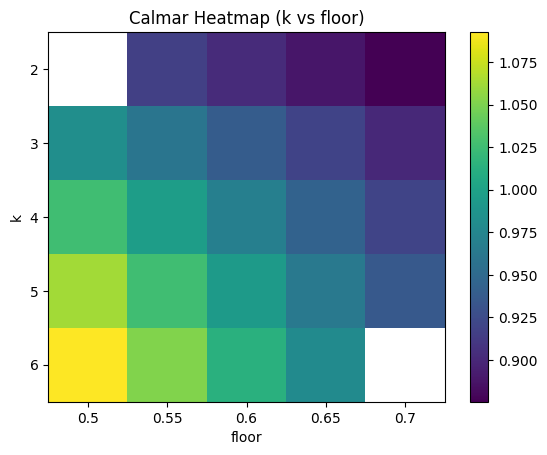

In [107]:
import matplotlib.pyplot as plt

plt.imshow(pivot, aspect='auto')
plt.colorbar()
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Calmar Heatmap (k vs floor)")
plt.xlabel("floor")
plt.ylabel("k")
plt.show()

**Refactoring the DB schema**

In [108]:
# create a table

cursor.execute("""
               CREATE TABLE IF NOT EXISTS risk_parameter_experiments (
               experiment_id TEXT PRIMARY KEY,
               project TEXT,
               k REAL,
               floor REAL,
               sharpe REAL,
               mdd REAL,
               cagr REAL,
               vol REAL,
               calmar REAL,
               avg_exposure
               )
               """)

conn.commit()

In [109]:
# Insert autoexperiment results

df_auto = pd.read_sql("""
                      SELECT
                        experiment_id,
                        strategy,
                        sharpe,
                        mdd,
                        cagr,
                        vol,
                        calmar,
                        avg_exposure
                      FROM strategy_metrics
                      WHERE experiment_id LIKE 'auto_smooth_dd_%'
                      """, conn)

In [110]:
# Extract k and floor

import re

def extract_k_floor(exp_id):
    match = re.search(r"_k(\d+)_floor([0-9_]+)", exp_id)
    if not match:
        return None, None
    
    k = float(match.group(1))
    floor = float(match.group(2).replace("_", "."))
    return k, floor

df_auto[["k", "floor"]] = df_auto["experiment_id"].apply(
    lambda x: pd.Series(extract_k_floor(x))
)

In [111]:
#prepare clean table

df_risk_params = df_auto[[
    "experiment_id",
    "k",
    "floor",
    "sharpe",
    "mdd",
    "cagr",
    "vol",
    "calmar",
    "avg_exposure"
]].copy()

df_risk_params["project"] = "Project 05 Risk Engine"

df_risk_params = df_risk_params[[
    "experiment_id",
    "project",
    "k",
    "floor",
    "sharpe",
    "mdd",
    "cagr",
    "vol",
    "calmar",
    "avg_exposure"
]]

In [113]:
cursor.execute("DROP TABLE IF EXISTS risk_parameter_experiments")
conn.commit()

In [114]:
cursor.execute("""
CREATE TABLE risk_parameter_experiments (
    experiment_id TEXT PRIMARY KEY,
    project TEXT,
    k REAL,
    floor REAL,
    sharpe REAL,
    mdd REAL,
    cagr REAL,
    vol REAL,
    calmar REAL,
    avg_exposure REAL
)
""")
conn.commit()

In [115]:
df_risk_params.to_sql(
    "risk_parameter_experiments",
    conn,
    if_exists="append",
    index=False
)

23

In [116]:
pd.read_sql("PRAGMA table_info(risk_parameter_experiments);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,experiment_id,TEXT,0,None,1
1,1,project,TEXT,0,None,0
2,2,k,REAL,0,None,0
3,3,floor,REAL,0,None,0
4,4,sharpe,REAL,0,None,0
5,5,mdd,REAL,0,None,0
6,6,cagr,REAL,0,None,0
7,7,vol,REAL,0,None,0
8,8,calmar,REAL,0,None,0
9,9,avg_exposure,REAL,0,None,0


In [117]:
pd.read_sql("""
            SELECT k, floor, calmar
            FROM risk_parameter_experiments
            ORDER BY calmar DESC
            """, conn)

,k,floor,calmar
0,6.0,0.50,1.092532
1,5.0,0.50,1.062269
2,6.0,0.55,1.051015
3,5.0,0.55,1.026370
4,4.0,0.50,1.025815
5,6.0,0.60,1.013488
6,4.0,0.55,0.996298
7,5.0,0.60,0.993577
8,3.0,0.50,0.982341
9,6.0,0.65,0.979407
